In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
df=df.drop_duplicates()

In [5]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
mean_cols=["trestbps","chol","thalch","oldpeak","ca"]
median_cols=["fbs","restecg","exang","slope","thal"]


for col in mean_cols:
    if col in df.columns:
        df[col]=df[col].fillna(df[col].mean())

In [7]:
for col in median_cols:
    if col in df.columns:
        df[col]=df[col].fillna(df[col].mode()[0])

C:\Users\Saibaba\AppData\Local\Temp\ipykernel_8664\959097815.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col]=df[col].fillna(df[col].mode()[0])


In [8]:
df.isna().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [9]:
df1=df[["age","cp","chol","thalch"]]
df2=df[["exang","slope","num"]]

In [10]:
merged_df=pd.concat([df1,df2],axis=1)
merged_df

,age,cp,chol,thalch,exang,slope,num
0,63,typical angina,233.0,150.000000,False,downsloping,0
1,67,asymptomatic,286.0,108.000000,True,flat,2
2,67,asymptomatic,229.0,129.000000,True,flat,1
3,37,non-anginal,250.0,187.000000,False,downsloping,0
4,41,atypical angina,204.0,172.000000,False,upsloping,0
...,...,...,...,...,...,...,...
915,54,asymptomatic,333.0,154.000000,False,flat,1
916,62,typical angina,139.0,137.545665,False,flat,0
917,55,asymptomatic,223.0,100.000000,False,flat,2
918,58,asymptomatic,385.0,137.545665,False,flat,0


In [11]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

label_encoder=LabelEncoder()
scaler=StandardScaler()

cat_col=["sex","dataset","cp","restecg","slope","thal"]
num_cols=["age","trestbps","chol","thalch","oldpeak","ca"]

for col in cat_col:
    df[col]=label_encoder.fit_transform(df[col].astype(str))
df[num_cols]=scaler.fit_transform(df[num_cols])

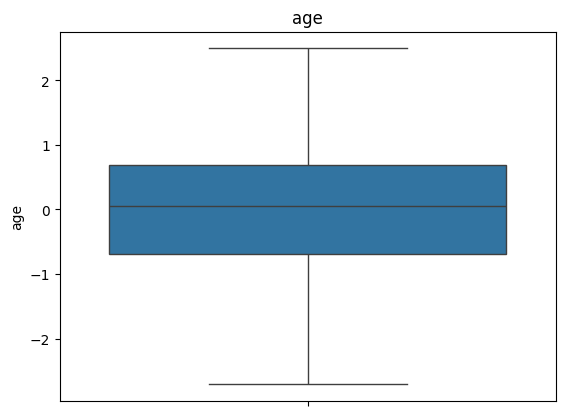

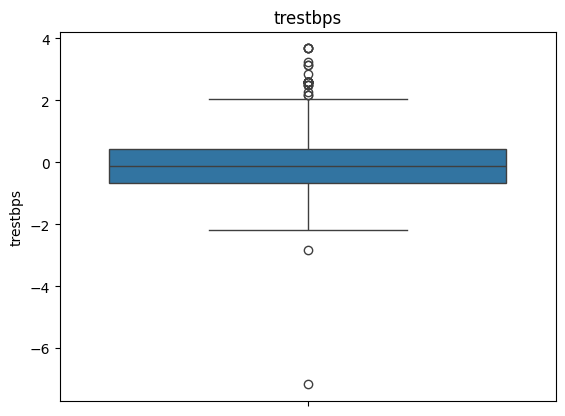

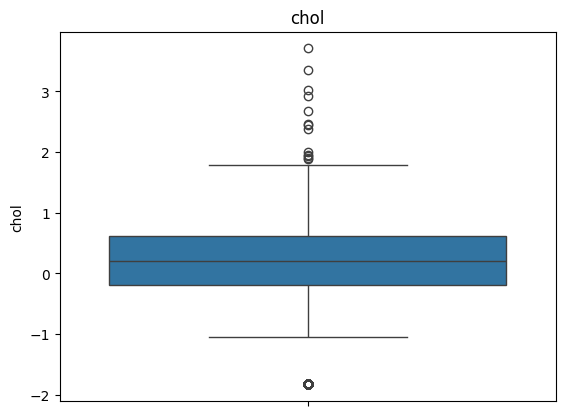

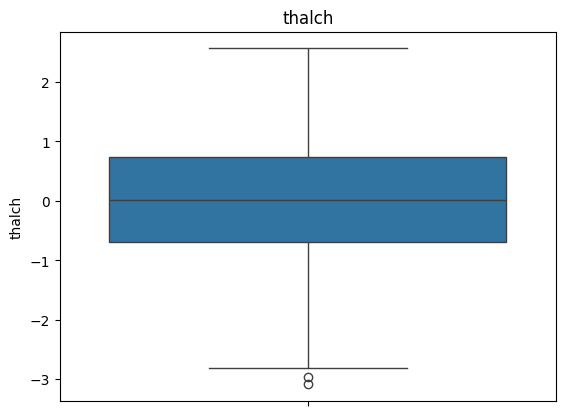

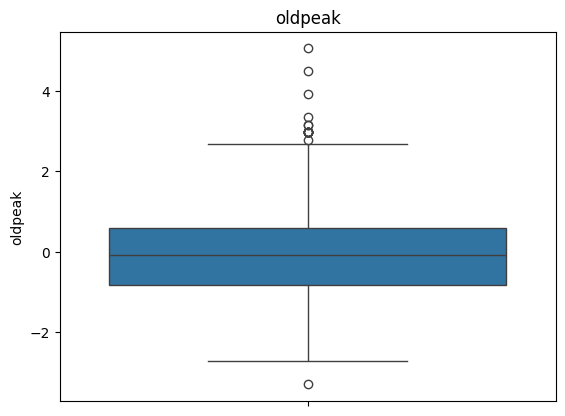

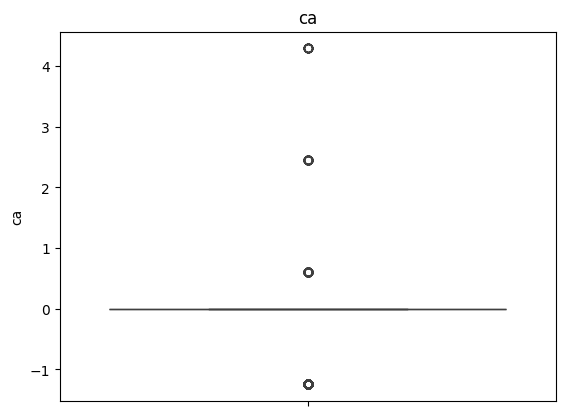

In [12]:
for col in num_cols:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [13]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]


for col in num_cols:
    df = remove_outliers(df, col)

    

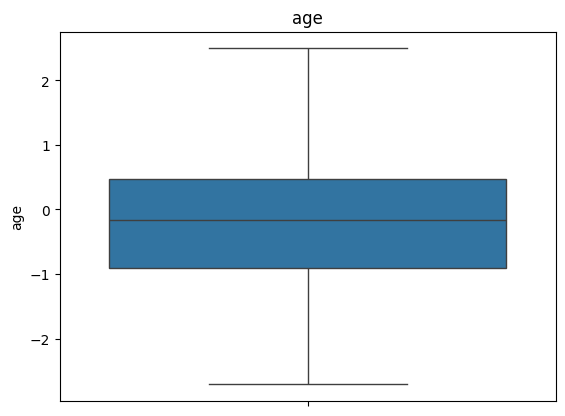

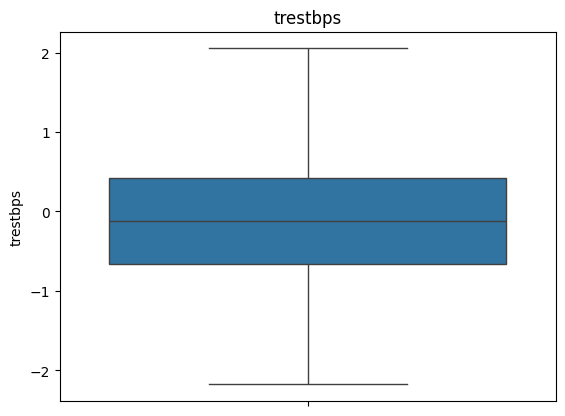

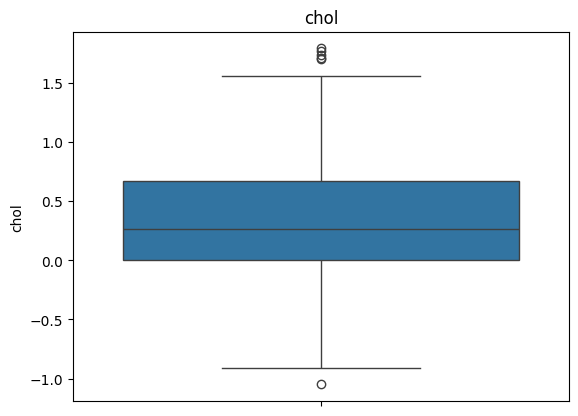

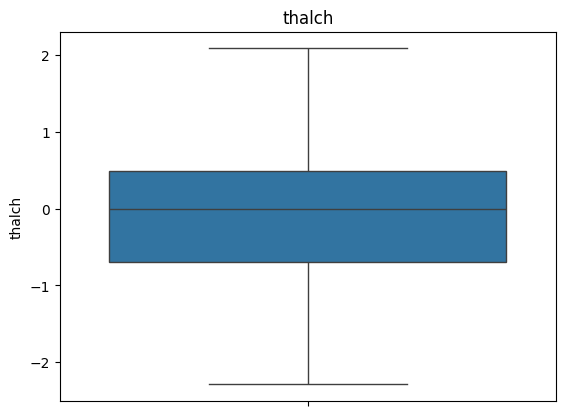

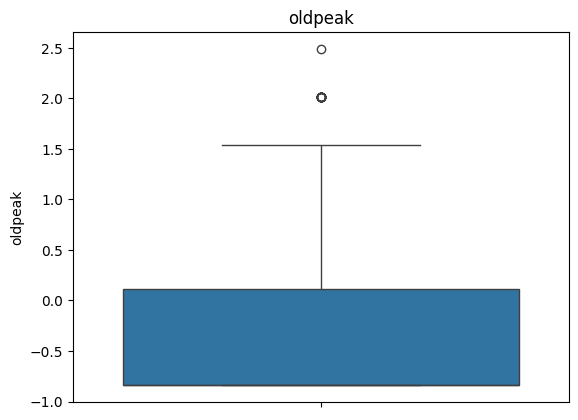

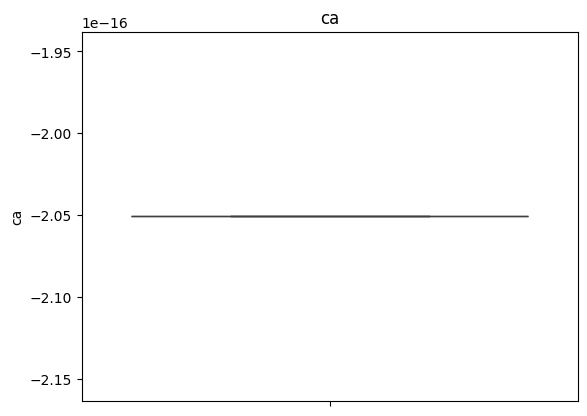

In [14]:
for col in num_cols:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [15]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
166,167,-0.160397,1,0,2,0.318305,0.219192,False,1,1.251922,False,-0.834397,2,-2.050756e-16,1,0
192,193,-1.115855,1,0,0,-0.007183,0.439581,True,0,0.217089,True,-0.739448,1,-2.050756e-16,2,1
287,288,0.476575,1,0,1,-0.386918,0.191643,False,1,0.256891,False,-0.454603,1,-2.050756e-16,2,0
302,303,-1.646666,1,0,2,0.318305,-0.221586,False,1,1.411127,False,-0.834397,2,-2.050756e-16,1,0
303,304,-2.708286,1,0,1,-0.115679,-0.616449,False,0,1.888743,False,-0.834397,1,-2.050756e-16,1,0


In [16]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
y = df['num']
X = df.drop(['id', 'num'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [17]:
from sklearn.metrics import accuracy_score, classification_report,accuracy_score
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\Saibaba\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# Step 10: Evaluate Model Performance
print(f"Accuracy:", accuracy_score(y_test, y_pred))
print(f"\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90        51
           1       0.60      0.60      0.60        20
           2       1.00      0.50      0.67         6
           3       0.14      0.20      0.17         5
           4       0.00      0.00      0.00         2

    accuracy                           0.75        84
   macro avg       0.52      0.44      0.47        84
weighted avg       0.75      0.75      0.74        84



C:\Users\Saibaba\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Saibaba\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Saibaba\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [24]:
# Correct new sample (14 features in the right order)
# Example: [age, sex, dataset, cp, trestbps, chol, fbs, restecg, thalch, exang, oldpeak, slope, ca, thal]
new_data = [[-0.2, 1, 0, 2, 0.25, 0.3, 1, 1, 1.2, 0, 0.0, 2, 1, 2]]

# Predict the class
prediction = model.predict(new_data)

print("Predicted Heart Disease Class:", prediction[0])


Predicted Heart Disease Class: 0


C:\Users\Saibaba\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
